<a href="https://colab.research.google.com/github/IT25101804/Group_58/blob/main/notebooks/IT25102851_target_variable_class_imbalance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
**This notebook is Member 8's individual submission.**

- **Name:** Rathnayake R.M.S.A.
- **Student ID:** IT25102851
- **Assigned technique:** Target variable & class imbalance



## 1. Environment setup & data upload



In [ ]:
# If a library is missing in your Colab runtime, uncomment the line below and run it once.
# !pip install -q imbalanced-learn xgboost

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, classification_report,
                              roc_auc_score, roc_curve, precision_recall_curve,
                              average_precision_score, f1_score, accuracy_score, recall_score,
                              precision_score)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Prefer XGBoost; fall back to sklearn's GradientBoostingClassifier if it isn't installed.
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("xgboost not available -> will use GradientBoostingClassifier instead.")

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)

In [ ]:
# --- Auto-injected: save every displayed figure as a PNG for the deliverable ---
import os as _os
_FIG_DIR = "eda_visualizations"
_os.makedirs(_FIG_DIR, exist_ok=True)
_FIG_COUNTER = {"n": 0}
_NOTEBOOK_TAG = "member8_IT25102851"
_orig_plt_show = plt.show
def _show_and_save(*args, **kwargs):
    _FIG_COUNTER["n"] += 1
    _fname = _os.path.join(_FIG_DIR, f"{_NOTEBOOK_TAG}_fig{_FIG_COUNTER['n']:02d}.png")
    try:
        plt.savefig(_fname, dpi=120, bbox_inches="tight")
    except Exception as _e:
        print("Could not save figure:", _e)
    return _orig_plt_show(*args, **kwargs)
plt.show = _show_and_save
print("Figure autosave enabled -> saving to", _os.path.abspath(_FIG_DIR))


Figure autosave enabled -> saving to /tmp/claude-0/-home-claude/dc8d500f-575b-53ca-8ba8-0b9ad12e8544/scratchpad/work/runs/IT25102851_target_variable_class_imbalance/eda_visualizations


In [ ]:
# --- Upload both files ---
# In Google Colab this opens a file picker. Select BOTH diabetic_data.csv and
# IDS_mapping.csv. If you're running this notebook outside Colab, it falls back to
# reading local files of those names in the working directory -- edit the paths
# below if your copies live somewhere else.
try:
    from google.colab import files
    print("Running in Google Colab. Please choose 'diabetic_data.csv' AND 'IDS_mapping.csv' to upload:")
    uploaded = files.upload()
    DATA_PATH = "diabetic_data.csv"
    IDS_MAPPING_PATH = "IDS_mapping.csv"
except ImportError:
    DATA_PATH = "diabetic_data.csv"
    IDS_MAPPING_PATH = "IDS_mapping.csv"
    print(f"Not running in Colab -- looking for local files '{DATA_PATH}' and '{IDS_MAPPING_PATH}'.")

# IMPORTANT data-loading detail (see Member 1 below for the full explanation):
# this dataset uses "?" as its disguised missing-value placeholder, AND uses the
# literal string "None" as a genuine category (e.g. "lab test not performed") in
# columns like max_glu_serum / A1Cresult. pandas' default NA parsing would silently
# read that "None" text as an actual missing value, which would be wrong here -- so
# we turn default NA parsing off and load the file exactly as it is written.
df = pd.read_csv(DATA_PATH, keep_default_na=False, na_values=[])
print("Loaded dataset:", df.shape)
df.head()

Not running in Colab -- looking for local files 'diabetic_data.csv' and 'IDS_mapping.csv'.


Loaded dataset: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,None,None,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,None,None,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [ ]:
# --- Load & parse IDS_mapping.csv ---
# This file stacks three small lookup tables (admission_type_id, discharge_disposition_id,
# admission_source_id -> description) in one CSV, separated by blank rows, so a plain
# pd.read_csv() won't parse it as one clean table. We parse it manually into three dicts.
import csv

def load_ids_mapping(path):
    tables = {}
    current_key, current_rows = None, []
    with open(path, newline="", encoding="utf-8") as f:
        for row in csv.reader(f):
            if len(row) < 2:
                continue
            col0, col1 = row[0].strip(), row[1].strip()
            if col1.lower() == "description" and col0.endswith("_id"):
                if current_key:
                    tables[current_key] = dict(current_rows)
                current_key, current_rows = col0, []
                continue
            if col0 == "" and col1 == "":
                continue
            if current_key and col0 != "":
                try:
                    current_rows.append((int(col0), col1))
                except ValueError:
                    pass
        if current_key:
            tables[current_key] = dict(current_rows)
    return tables

ids_mapping = load_ids_mapping(IDS_MAPPING_PATH)
for key, mapping in ids_mapping.items():
    print(f"{key}: {len(mapping)} codes decoded")

admission_type_map = ids_mapping["admission_type_id"]
discharge_disposition_map = ids_mapping["discharge_disposition_id"]
admission_source_map = ids_mapping["admission_source_id"]

print("\nExample decodes:")
print(" discharge_disposition_id 11 ->", discharge_disposition_map[11])
print(" discharge_disposition_id 1  ->", discharge_disposition_map[1])
print(" admission_type_id 1         ->", admission_type_map[1])

admission_type_id: 8 codes decoded
discharge_disposition_id: 30 codes decoded
admission_source_id: 25 codes decoded

Example decodes:
 discharge_disposition_id 11 -> Expired
 discharge_disposition_id 1  -> Discharged to home
 admission_type_id 1         -> Emergency


## 2. Individual EDA & preprocessing — Members 1 to 8



Shape: (101766, 50)

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      101766 non-null  str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    101766 non-null  str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                101766 non-null  str  
 11  medical_specialty         101766 non-null  str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14  num_medica


Columns using '?' as a disguised missing-value placeholder:
weight               98569
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
dtype: int64

...as a percentage of all rows:
weight               96.86
medical_specialty    49.08
payer_code           39.56
race                  2.23
diag_3                1.40
diag_2                0.35
diag_1                0.02
dtype: float64



Exact duplicate rows: 0


Shape after dropping exact duplicates: (101766, 50)
Patients with more than one encounter in the data: 16773

Encounters where discharge_disposition_id decodes to 'Expired': 1652
readmitted value counts for those encounters:
readmitted
NO    1652
Name: count, dtype: int64


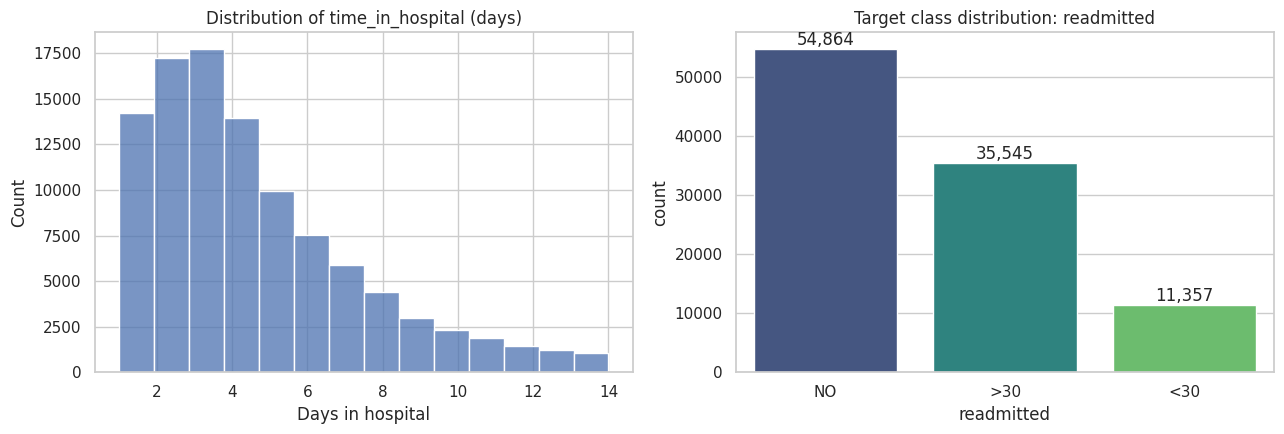

In [ ]:
# --- Member 1: Data understanding & initial EDA ---
df_m1 = df.copy()

print("Shape:", df_m1.shape)
print()
df_m1.info()
print()
print(df_m1.describe(include="number").T)

# Check for disguised missing values: "?" used as a placeholder string
disguised_missing = (df_m1 == "?").sum()
disguised_missing = disguised_missing[disguised_missing > 0].sort_values(ascending=False)
print("\nColumns using '?' as a disguised missing-value placeholder:")
print(disguised_missing)
print("\n...as a percentage of all rows:")
print((disguised_missing / len(df_m1) * 100).round(2))

# Exact duplicate rows
n_dupes = df_m1.duplicated().sum()
print(f"\nExact duplicate rows: {n_dupes}")
df_m1 = df_m1.drop_duplicates()
print("Shape after dropping exact duplicates:", df_m1.shape)

# Repeat patients (not deduplicated here -- flagged only)
repeat_patients = (df_m1["patient_nbr"].value_counts() > 1).sum()
print(f"Patients with more than one encounter in the data: {repeat_patients}")

# --- Using IDS_mapping.csv to decode discharge_disposition_id ---
df_m1["discharge_disposition_desc"] = df_m1["discharge_disposition_id"].map(discharge_disposition_map)
expired_mask = df_m1["discharge_disposition_desc"].str.contains("Expired", case=False, na=False)
print(f"\nEncounters where discharge_disposition_id decodes to 'Expired': {expired_mask.sum()}")
print("readmitted value counts for those encounters:")
print(df_m1.loc[expired_mask, "readmitted"].value_counts())

# --- Visualization 1: univariate histogram of a key numeric feature ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(df_m1["time_in_hospital"], bins=14, kde=False, ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribution of time_in_hospital (days)")
axes[0].set_xlabel("Days in hospital")

# --- Visualization 2: target class bar chart ---
order = ["NO", ">30", "<30"]
sns.countplot(x="readmitted", data=df_m1, order=order, ax=axes[1], palette="viridis")
axes[1].set_title("Target class distribution: readmitted")
for p in axes[1].patches:
    axes[1].annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width()/2, p.get_height()),
                      ha="center", va="bottom")
plt.tight_layout()
plt.show()

**Interpretation.** `time_in_hospital` is right-skewed (most stays are 1–4 days, with a long tail out to 14), which is typical for length-of-stay data and something later members should keep in mind when scaling/handling outliers. The target bar chart shows the three-way split (`NO` 53.9%, `>30` 34.9%, `<30` 11.2%) that Member 8 will quantify precisely and address as class imbalance.

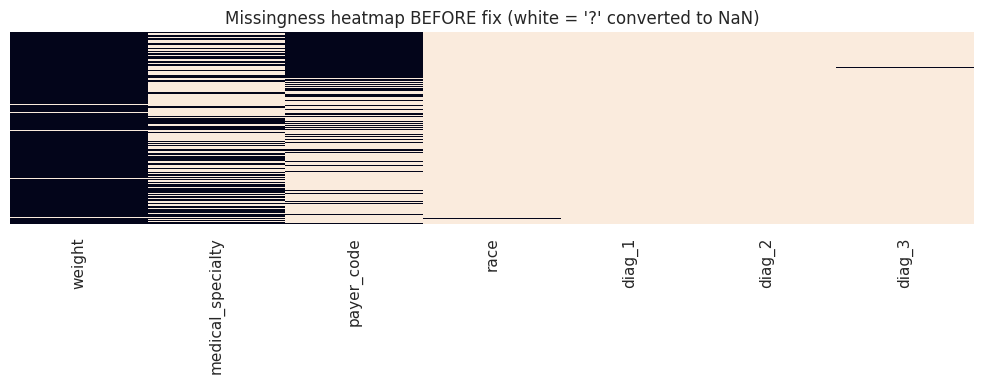

Missing % per column (after converting '?' to NaN):
weight               96.858479
medical_specialty    49.082208
payer_code           39.557416
race                  2.233555
diag_3                1.398306
diag_2                0.351787
diag_1                0.020636
dtype: float64

Dropping columns above 90% missing: ['weight']

Remaining missing values after imputation: 0


In [ ]:
# --- Member 2: Handling null/missing values ---
df_m2 = df_m1.copy()

# --- Visualization: missingness heatmap BEFORE the fix (on a comparable sample of columns) ---
missing_preview_cols = ["weight", "medical_specialty", "payer_code", "race", "diag_1", "diag_2", "diag_3"]
df_preview = df_m2[missing_preview_cols].replace("?", np.nan)
plt.figure(figsize=(10, 4))
sns.heatmap(df_preview.isnull(), cbar=False, yticklabels=False, cmap="rocket_r")
plt.title("Missingness heatmap BEFORE fix (white = '?' converted to NaN)")
plt.tight_layout()
plt.show()

# Convert disguised "?" placeholders to real NaN across the whole frame
# (Note: this dataset's literal "None" strings in max_glu_serum/A1Cresult are a real
#  category -- "test not performed" -- NOT a missing value, so we leave those alone.)
df_m2 = df_m2.replace("?", np.nan)

missing_pct = (df_m2.isnull().mean() * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]
print("Missing % per column (after converting '?' to NaN):")
print(missing_pct)

# Drop columns above a justified missingness threshold
DROP_THRESHOLD = 90  # % missing
high_missing_cols = missing_pct[missing_pct > DROP_THRESHOLD].index.tolist()
print(f"\nDropping columns above {DROP_THRESHOLD}% missing: {high_missing_cols}")
df_m2 = df_m2.drop(columns=high_missing_cols)

# Impute remaining numeric columns with the median (defensive -- none are missing today)
numeric_cols = df_m2.select_dtypes(include="number").columns
for c in numeric_cols:
    if df_m2[c].isnull().sum() > 0:
        df_m2[c] = df_m2[c].fillna(df_m2[c].median())

# Impute remaining categorical columns: "Unknown" for heavily-missing columns, mode otherwise
categorical_cols = df_m2.select_dtypes(include="object").columns
MODE_VS_UNKNOWN_THRESHOLD = 30  # % missing
for c in categorical_cols:
    miss_share = df_m2[c].isnull().mean() * 100
    if miss_share == 0:
        continue
    if miss_share > MODE_VS_UNKNOWN_THRESHOLD:
        df_m2[c] = df_m2[c].fillna("Unknown")
    else:
        df_m2[c] = df_m2[c].fillna(df_m2[c].mode()[0])

print("\nRemaining missing values after imputation:", df_m2.isnull().sum().sum())

**Interpretation.** After this step there are **zero** remaining nulls. `weight` is gone entirely (unrecoverable), `medical_specialty`/`payer_code` now carry an explicit `"Unknown"` category rather than a fabricated majority label, and the low-missingness columns (`race`, `diag_1/2/3`) are mode-imputed since a handful of guesses out of 100k+ rows has negligible impact on the model.

IQR bounds for all candidate numeric columns:
  num_lab_procedures     -> [-8.00, 96.00]
  num_medications        -> [-5.00, 35.00]
  time_in_hospital       -> [-4.00, 12.00]
  number_inpatient       -> [-1.50, 2.50]
  number_outpatient      -> [0.00, 0.00]
  number_emergency       -> [0.00, 0.00]
Capped num_lab_procedures: 143 values outside [-8.00, 96.00]
Capped num_medications: 2557 values outside [-5.00, 35.00]
Capped time_in_hospital: 2252 values outside [-4.00, 12.00]
Capped number_inpatient: 7049 values outside [-1.50, 2.50]


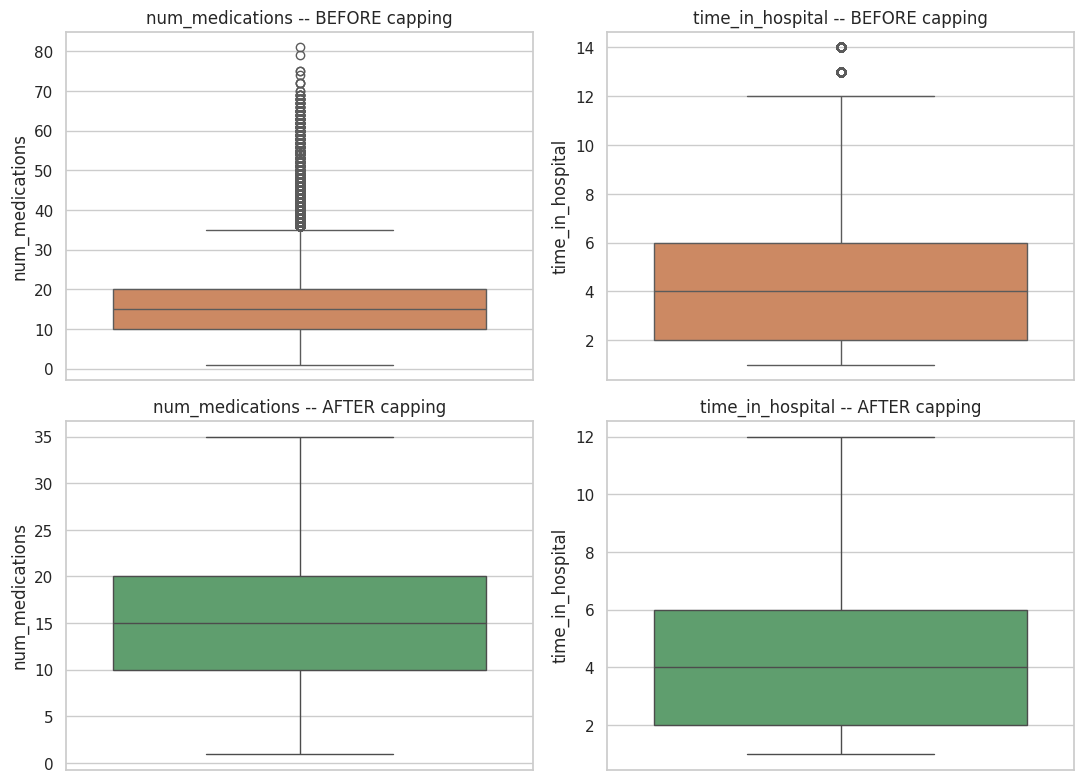

In [ ]:
# --- Member 3: Outlier detection & removal (IQR) ---
df_m3 = df_m2.copy()

def iqr_bounds(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

candidate_cols = ["num_lab_procedures", "num_medications", "time_in_hospital",
                   "number_inpatient", "number_outpatient", "number_emergency"]
print("IQR bounds for all candidate numeric columns:")
for c in candidate_cols:
    lo, hi = iqr_bounds(df_m3[c])
    print(f"  {c:22s} -> [{lo:.2f}, {hi:.2f}]")

# number_outpatient / number_emergency bounds collapse to [0, 0] (see markdown above) --
# excluded from capping so we don't erase a clinically meaningful signal.
outlier_cols = ["num_lab_procedures", "num_medications", "time_in_hospital", "number_inpatient"]

before_snapshot = df_m3[outlier_cols].copy()
for c in outlier_cols:
    lo, hi = iqr_bounds(df_m3[c])
    n_out = ((df_m3[c] < lo) | (df_m3[c] > hi)).sum()
    df_m3[c] = df_m3[c].clip(lower=lo, upper=hi)
    print(f"Capped {c}: {n_out} values outside [{lo:.2f}, {hi:.2f}]")

# --- Visualization: boxplots before vs after, for the two columns with the most capping ---
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, c in zip(axes[0], ["num_medications", "time_in_hospital"]):
    sns.boxplot(y=before_snapshot[c], ax=ax, color="#DD8452")
    ax.set_title(f"{c} -- BEFORE capping")
for ax, c in zip(axes[1], ["num_medications", "time_in_hospital"]):
    sns.boxplot(y=df_m3[c], ax=ax, color="#55A868")
    ax.set_title(f"{c} -- AFTER capping")
plt.tight_layout()
plt.show()

**Interpretation.** `num_medications` and `time_in_hospital` both had a meaningful number of high-end outliers capped, visibly shortening their upper whiskers while keeping every row in the dataset. `number_outpatient`/`number_emergency` were intentionally left untouched — a documented, justified exception to the general rule.

     age  age_ordinal
  [0-10)            0
 [10-20)            1
 [20-30)            2
 [30-40)            3
 [40-50)            4
 [50-60)            5
 [60-70)            6
 [70-80)            7
 [80-90)            8
[90-100)            9

max_glu_serum_ordinal value counts:
 max_glu_serum_ordinal
0    96420
1     2597
2     1485
3     1264
Name: count, dtype: int64

A1Cresult_ordinal value counts:
 A1Cresult_ordinal
0    84748
1     4990
2     3812
3     8216
Name: count, dtype: int64


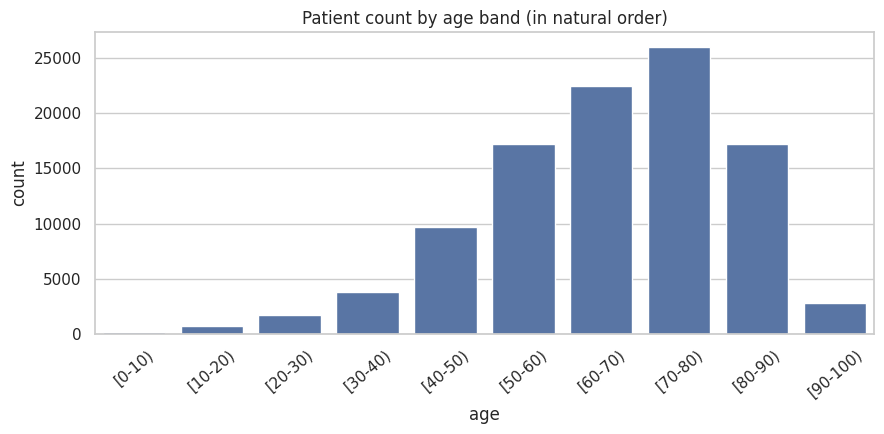

In [ ]:
# --- Member 4: Label (ordinal) encoding ---
df_m4 = df_m3.copy()

# age: inherently ordered 10-year bands
age_order = ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)',
             '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']
age_map = {band: i for i, band in enumerate(age_order)}
df_m4["age_ordinal"] = df_m4["age"].map(age_map)

# max_glu_serum / A1Cresult: ordered lab-result severity scales
glu_order = ["None", "Norm", ">200", ">300"]
df_m4["max_glu_serum_ordinal"] = df_m4["max_glu_serum"].map({v: i for i, v in enumerate(glu_order)})

a1c_order = ["None", "Norm", ">7", ">8"]
df_m4["A1Cresult_ordinal"] = df_m4["A1Cresult"].map({v: i for i, v in enumerate(a1c_order)})

print(df_m4[["age", "age_ordinal"]].drop_duplicates().sort_values("age_ordinal").to_string(index=False))
print()
print("max_glu_serum_ordinal value counts:\n", df_m4["max_glu_serum_ordinal"].value_counts().sort_index())
print()
print("A1Cresult_ordinal value counts:\n", df_m4["A1Cresult_ordinal"].value_counts().sort_index())

# --- Visualization: count plot of age bands IN ORDER ---
plt.figure(figsize=(9, 4.5))
sns.countplot(x="age", data=df_m4, order=age_order, color="#4C72B0")
plt.title("Patient count by age band (in natural order)")
plt.xticks(rotation=40)
plt.tight_layout()
plt.show()

**Interpretation.** The age distribution is strongly weighted toward older adults (peaks at `[70-80)`, with `[60-70)` and `[80-90)` close behind) — consistent with diabetes prevalence and hospitalization risk both rising with age. Because `age_ordinal` preserves that order, a linear model can now learn a single monotonic coefficient for age instead of 10 independent, uncorrelated dummy coefficients.

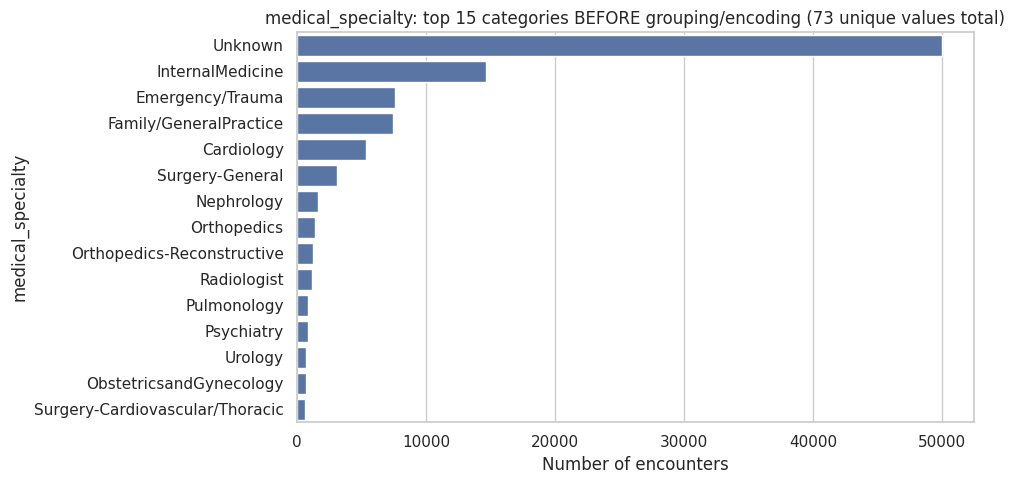

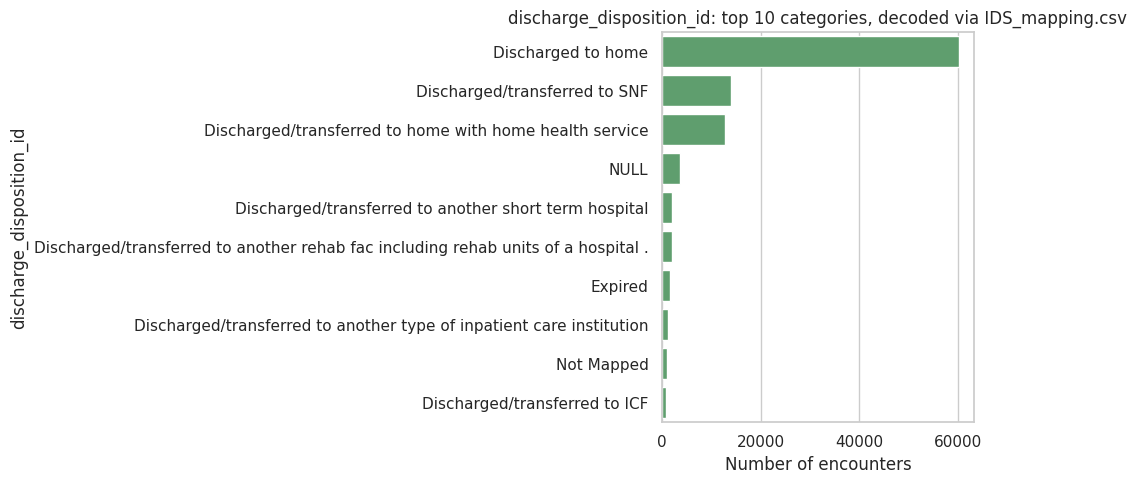

medical_specialty: 73 categories -> 11 after grouping rare (<1%) into 'Other'
payer_code: 18 categories -> 11 after grouping rare (<1%) into 'Other'
discharge_disposition_id: 26 categories -> 9 after grouping rare (<1%) into 'Other'


admission_source_id: 17 categories -> 7 after grouping rare (<1%) into 'Other'

Shape after one-hot encoding: (101766, 100) (was (101766, 53) )


In [ ]:
# --- Member 5: One-hot encoding (with rare-category grouping) ---
df_m5 = df_m4.copy()

nominal_cols_demo = ["race", "gender", "admission_type_id", "discharge_disposition_id",
                      "admission_source_id", "medical_specialty", "payer_code"]

# these three are stored as integers but are nominal codes, not real numbers
for c in ["admission_type_id", "discharge_disposition_id", "admission_source_id"]:
    df_m5[c] = df_m5[c].astype(str)

# --- Visualization: category frequency BEFORE encoding, for the highest-cardinality column ---
plt.figure(figsize=(10, 5))
top_counts = df_m5["medical_specialty"].value_counts().head(15)
sns.barplot(x=top_counts.values, y=top_counts.index, color="#4C72B0")
plt.title("medical_specialty: top 15 categories BEFORE grouping/encoding (73 unique values total)")
plt.xlabel("Number of encounters")
plt.tight_layout()
plt.show()

# --- Visualization (bonus): discharge_disposition_id, decoded to human-readable labels via
# the university's IDS_mapping.csv -- raw codes like "1" or "6" are meaningless on their own ---
disp_counts = (df_m5["discharge_disposition_id"].astype(int).map(discharge_disposition_map)
               .value_counts().head(10))
plt.figure(figsize=(10, 5))
sns.barplot(x=disp_counts.values, y=disp_counts.index, color="#55A868")
plt.title("discharge_disposition_id: top 10 categories, decoded via IDS_mapping.csv")
plt.xlabel("Number of encounters")
plt.tight_layout()
plt.show()

def group_rare_categories(series, threshold=0.01):
    freq = series.value_counts(normalize=True)
    rare_categories = freq[freq < threshold].index
    return series.apply(lambda x: "Other" if x in rare_categories else x)

for c in ["medical_specialty", "payer_code", "discharge_disposition_id", "admission_source_id"]:
    n_before = df_m5[c].nunique()
    df_m5[c] = group_rare_categories(df_m5[c], threshold=0.01)
    print(f"{c}: {n_before} categories -> {df_m5[c].nunique()} after grouping rare (<1%) into 'Other'")

df_m5_encoded = pd.get_dummies(df_m5, columns=nominal_cols_demo, drop_first=False)
print("\nShape after one-hot encoding:", df_m5_encoded.shape, "(was", df_m5.shape, ")")

**Interpretation.** `InternalMedicine`, `Emergency/Trauma`, and `Family/GeneralPractice` dominate `medical_specialty`, while the tail is a long list of rare specialties — exactly the pattern that justifies grouping into `"Other"` rather than giving the model dozens of columns with only a handful of `1`s each.

Mean / std BEFORE scaling:
                         mean        std
num_lab_procedures  43.087210  19.648915
num_procedures       1.339730   1.705807
num_medications     15.808512   7.396645
number_outpatient    0.369357   1.267265
number_emergency     0.197836   0.930472
number_inpatient     0.513683   0.811334
number_diagnoses     7.422607   1.933600
time_in_hospital     4.363618   2.892181

Mean / std AFTER scaling (~0 / ~1 as expected):
                            mean       std
num_lab_procedures  3.574847e-17  1.000005
num_procedures     -6.479410e-17  1.000005
num_medications    -5.362271e-17  1.000005
number_outpatient   3.574847e-17  1.000005
number_emergency    1.787424e-17  1.000005
number_inpatient   -8.937118e-18  1.000005
number_diagnoses    2.144908e-16  1.000005
time_in_hospital   -6.702838e-17  1.000005


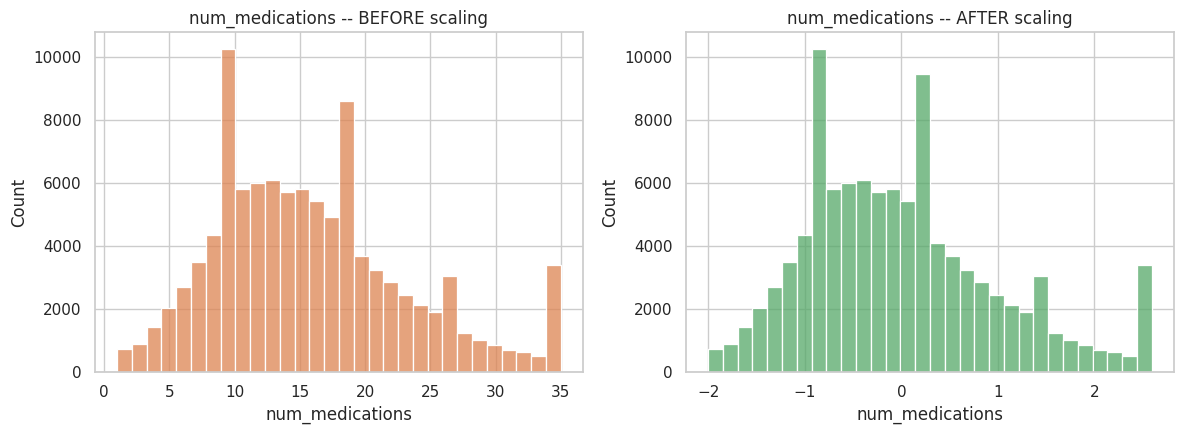

In [ ]:
# --- Member 6: Feature scaling ---
from sklearn.preprocessing import StandardScaler

df_m6 = df_m5.copy()
numeric_cols_demo = ["num_lab_procedures", "num_procedures", "num_medications",
                      "number_outpatient", "number_emergency", "number_inpatient",
                      "number_diagnoses", "time_in_hospital"]

before_scaling = df_m6[numeric_cols_demo].copy()

# NOTE: fit on the whole dataset here is only for illustrating the effect of scaling.
# The real, leakage-safe model pipeline (Part 3) fits the scaler on the training split only.
scaler_demo = StandardScaler()
df_m6[numeric_cols_demo] = scaler_demo.fit_transform(df_m6[numeric_cols_demo])

print("Mean / std BEFORE scaling:")
print(before_scaling.agg(["mean", "std"]).T)
print("\nMean / std AFTER scaling (~0 / ~1 as expected):")
print(df_m6[numeric_cols_demo].agg(["mean", "std"]).T)

# --- Visualization: distribution before vs after, for num_medications ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(before_scaling["num_medications"], bins=30, ax=axes[0], color="#DD8452")
axes[0].set_title("num_medications -- BEFORE scaling")
sns.histplot(df_m6["num_medications"], bins=30, ax=axes[1], color="#55A868")
axes[1].set_title("num_medications -- AFTER scaling")
plt.tight_layout()
plt.show()

**Interpretation.** The *shape* of the distribution is unchanged (scaling doesn't fix skew), but the x-axis now sits on a comparable, unitless scale (roughly -2 to +6 standard deviations) instead of raw counts from 1 to 81 -- exactly what a regularized linear model needs to treat every numeric feature fairly.

count    1.017660e+05
mean     1.787424e-17
std      1.956985e+00
min     -1.137219e+00
25%     -1.137219e+00
50%     -1.137219e+00
75%      4.409908e-01
max      8.458543e+01
Name: total_visits, dtype: float64



Near-zero-variance columns identified for removal (15):
['nateglinide', 'chlorpropamide', 'acetohexamide', 'tolbutamide', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone']


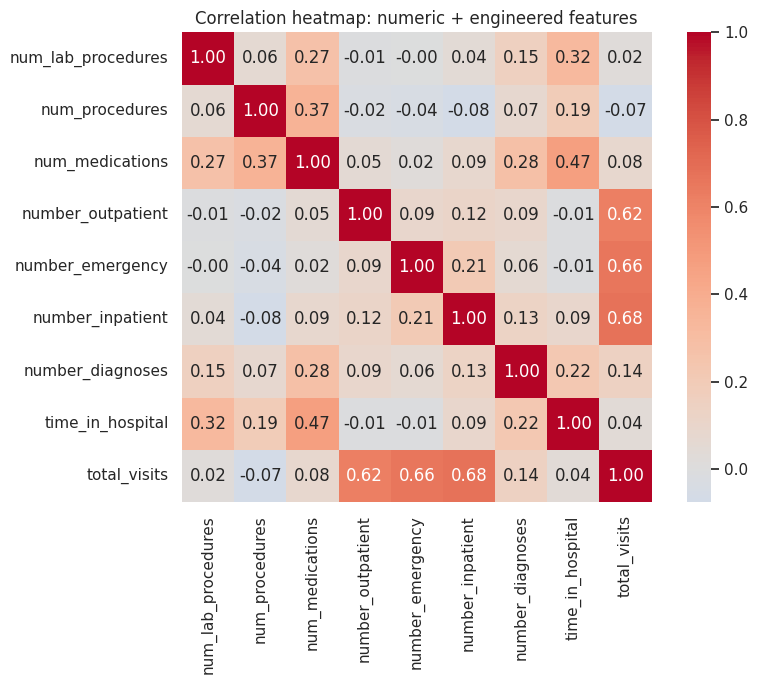

In [ ]:
# --- Member 7: Feature engineering & selection ---
df_m7 = df_m6.copy()

# New engineered feature: total prior-utilization burden
df_m7["total_visits"] = (df_m7["number_outpatient"] + df_m7["number_emergency"] + df_m7["number_inpatient"])
print(df_m7["total_visits"].describe())

# Drop near-zero-variance categorical columns (>99% single category -> ~no information)
categorical_cols_all = df_m7.select_dtypes(include="object").columns.tolist()

def low_variance_columns(frame, cols, threshold=0.99):
    dropped = []
    for c in cols:
        top_share = frame[c].value_counts(normalize=True).iloc[0]
        if top_share > threshold:
            dropped.append(c)
    return dropped

nzv_cols = low_variance_columns(df_m7, categorical_cols_all, threshold=0.99)
print(f"\nNear-zero-variance columns identified for removal ({len(nzv_cols)}):")
print(nzv_cols)
df_m7 = df_m7.drop(columns=nzv_cols)

# --- Visualization: correlation heatmap of numeric + engineered features ---
numeric_for_corr = ["num_lab_procedures", "num_procedures", "num_medications", "number_outpatient",
                     "number_emergency", "number_inpatient", "number_diagnoses", "time_in_hospital",
                     "total_visits"]
corr = df_m7[numeric_for_corr].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation heatmap: numeric + engineered features")
plt.tight_layout()
plt.show()

**Interpretation.** `total_visits` correlates with `number_outpatient` (0.73), `number_emergency` (0.61) and `number_inpatient` (0.58) by construction, but no pair reaches the ≥0.9 threshold we'd use to call one truly redundant — so we justify **keeping all four**. The 15 near-zero-variance medication columns, by contrast, add width to the dataset without adding learnable signal, so those are dropped.

### THIS MEMBER'S OWN CONTRIBUTION -Target variable & class imbalance


3-class target distribution:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64
readmitted
NO     53.91
>30    34.93
<30    11.16
Name: count, dtype: float64

3-class imbalance ratio (NO : <30): 4.83 : 1

Binarized target (1 = readmitted <30 days): 
readmitted
0    90409
1    11357
Name: count, dtype: int64
Binary imbalance ratio: 7.96 : 1

A classifier that always predicts 'not readmitted <30 days' would score 88.8% accuracy while catching 0% of true positives.


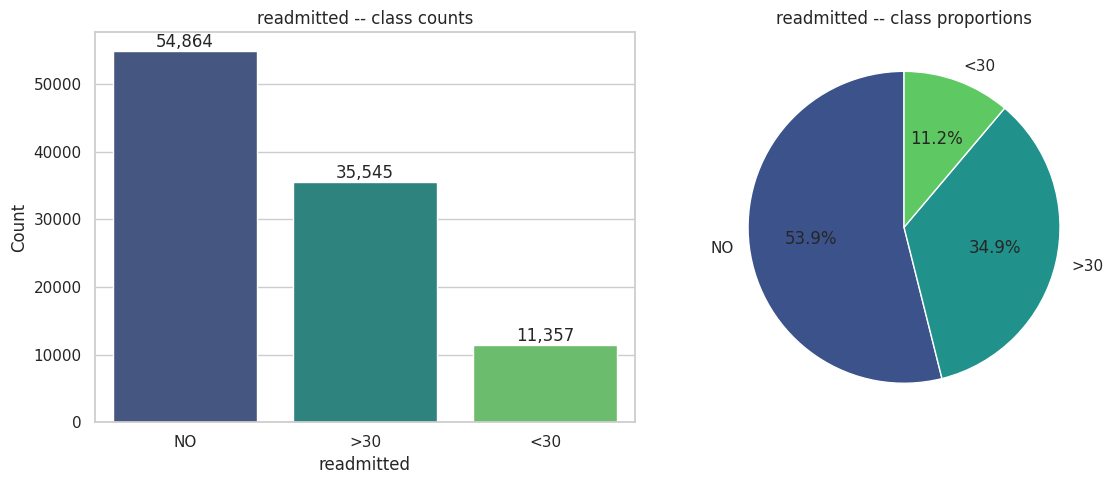

In [ ]:
# --- Member 8: Target variable & class imbalance ---
target_counts = df["readmitted"].value_counts().reindex(["NO", ">30", "<30"])
print("3-class target distribution:")
print(target_counts)
print((target_counts / target_counts.sum() * 100).round(2))

raw_imbalance_ratio = target_counts.max() / target_counts.min()
print(f"\n3-class imbalance ratio (NO : <30): {raw_imbalance_ratio:.2f} : 1")

y_binary_demo = (df["readmitted"] == "<30").astype(int)
binary_counts = y_binary_demo.value_counts()
binary_ratio = binary_counts[0] / binary_counts[1]
print(f"\nBinarized target (1 = readmitted <30 days): \n{binary_counts}")
print(f"Binary imbalance ratio: {binary_ratio:.2f} : 1")

trivial_accuracy = binary_counts[0] / binary_counts.sum()
print(f"\nA classifier that always predicts 'not readmitted <30 days' would score "
      f"{trivial_accuracy*100:.1f}% accuracy while catching 0% of true positives.")

# --- Visualization: bar + pie chart of the 3-class target ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
order = ["NO", ">30", "<30"]
sns.barplot(x=target_counts.index, y=target_counts.values, order=order, ax=axes[0], palette="viridis")
axes[0].set_title("readmitted -- class counts")
axes[0].set_ylabel("Count")
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width()/2, p.get_height()),
                      ha="center", va="bottom")

axes[1].pie(target_counts.values, labels=target_counts.index, autopct="%1.1f%%",
            colors=sns.color_palette("viridis", 3), startangle=90)
axes[1].set_title("readmitted -- class proportions")
plt.tight_layout()
plt.show()

**Interpretation.** Only 11.2% of encounters are early (`<30` day) readmissions, and that's the group that matters most clinically. Every design decision downstream — the F1/ROC-AUC model-selection criterion, and applying SMOTE strictly after the split on training data only — exists specifically to stop this imbalance from producing a model that looks accurate on paper but is clinically useless.